# HW03 Problem 2: FashionMNIST Image Classifier

Build an image classifier for the FashionMNIST dataset with PyTorch and torchvision, train it, evaluate it, and plot its training accuracy.

Submitted by Ponprom Rojanakiratikan

## Task 1: Load and split the FashionMNIST dataset

In [1]:
# Import the needed libraries
import torch
from torchvision import datasets
from torchvision.transforms import v2

# Define toTensor: convert images to a tensor, then to float32 scaled to [0, 1]
toTensor = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

# Load FashionMNIST training+validation set and test set, downloading into ./datasets if needed
train_and_valid_data = datasets.FashionMNIST(
    root="datasets",
    train=True,
    download=True,
    transform=toTensor,
)

test_data = datasets.FashionMNIST(
    root="datasets",
    train=False,
    download=True,
    transform=toTensor,
)

# Set the random seed right before splitting, then split into train (55000) and valid (5000)
torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [55000, 5000])

# Take the first training sample
X_sample, y_sample = train_data[0]

print(f"train_data size: {len(train_data)}")
print(f"valid_data size: {len(valid_data)}")
print(f"test_data size: {len(test_data)}")
print(f"X_sample shape: {X_sample.shape}, dtype: {X_sample.dtype}")


train_data size: 55000
valid_data size: 5000
test_data size: 10000
X_sample shape: torch.Size([1, 28, 28]), dtype: torch.float32


## Task 2: Build the DataLoaders

In [2]:
# Reuse train_data, valid_data and test_data from Task 1
from torch.utils.data import DataLoader

# Set the random seed right before creating the loaders
torch.manual_seed(42)

# Create the DataLoaders, all with batch size 32
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"train_loader batches: {len(train_loader)}")
print(f"valid_loader batches: {len(valid_loader)}")
print(f"test_loader batches: {len(test_loader)}")

images, labels = next(iter(train_loader))
print(f"first batch image shape: {images.shape}")
print(f"first batch label shape: {labels.shape}")


train_loader batches: 1719
valid_loader batches: 157
test_loader batches: 313
first batch image shape: torch.Size([32, 1, 28, 28])
first batch label shape: torch.Size([32])


## Task 3: Inspect a sample image and its class

In [3]:
# Take the first element of train_data
X_sample, y_sample = train_data[0]

# Each image has shape [channels, rows, columns]; FashionMNIST images are
# grayscale (one channel) and 28x28 pixels, so the shape is [1, 28, 28]

# Look up the class name for y_sample in the classes list
class_name = train_and_valid_data.classes[y_sample]

print(f"X_sample shape: {X_sample.shape}")
print(f"X_sample dtype: {X_sample.dtype}")
print(f"y_sample class name: {class_name}")


X_sample shape: torch.Size([1, 28, 28])
X_sample dtype: torch.float32
y_sample class name: Ankle boot


## Task 4: Define the image classifier model

In [4]:
# Import the needed libraries
from torch import nn


class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes),
        )

    def forward(self, X):
        return self.mlp(X)


# Select device: "cuda" if available, else "cpu"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Set the random seed right before creating the model
torch.manual_seed(42)

model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100, n_classes=10)
model = model.to(device)

# Loss function
xentropy = nn.CrossEntropyLoss()

n_params = sum(p.numel() for p in model.parameters())
print(f"total model parameters: {n_params}")

X_random = torch.rand(32, 1, 28, 28, device=device)
output = model(X_random)
print(f"output shape: {output.shape}")


Using device: cpu
total model parameters: 266610


output shape: torch.Size([32, 10])


## Task 5: Train the model

In [5]:
# Reuse the model, loss function, device and DataLoaders from Tasks 2 and 4
from torchmetrics import Accuracy

n_epochs = 20

# Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# Metric
accuracy = Accuracy(task="multiclass", num_classes=10).to(device)


def train2(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}

    for epoch in range(n_epochs):
        model.train()
        metric.reset()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            metric.update(y_pred, y_batch)

        train_loss /= len(train_loader.dataset)
        train_acc = metric.compute().item()

        model.eval()
        metric.reset()
        with torch.no_grad():
            for X_batch, y_batch in valid_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                metric.update(y_pred, y_batch)
        valid_acc = metric.compute().item()

        history["train_losses"].append(train_loss)
        history["train_metrics"].append(train_acc)
        history["valid_metrics"].append(valid_acc)

        print(
            f"epoch {epoch + 1}/{n_epochs} "
            f"- train_loss: {train_loss:.4f} "
            f"- train_acc: {train_acc:.4f} "
            f"- valid_acc: {valid_acc:.4f}"
        )

    return history


history = train2(model, optimizer, xentropy, accuracy, train_loader, valid_loader, n_epochs)


epoch 1/20 - train_loss: 0.6064 - train_acc: 0.7788 - valid_acc: 0.8198


epoch 2/20 - train_loss: 0.4051 - train_acc: 0.8509 - valid_acc: 0.8592


epoch 3/20 - train_loss: 0.3613 - train_acc: 0.8657 - valid_acc: 0.8564


epoch 4/20 - train_loss: 0.3337 - train_acc: 0.8752 - valid_acc: 0.8592


epoch 5/20 - train_loss: 0.3146 - train_acc: 0.8825 - valid_acc: 0.8660


...

epoch 16/20 - train_loss: 0.2087 - train_acc: 0.9207 - valid_acc: 0.8778


epoch 17/20 - train_loss: 0.2008 - train_acc: 0.9235 - valid_acc: 0.8802


epoch 18/20 - train_loss: 0.1962 - train_acc: 0.9271 - valid_acc: 0.8842


epoch 19/20 - train_loss: 0.1931 - train_acc: 0.9260 - valid_acc: 0.8900


epoch 20/20 - train_loss: 0.1864 - train_acc: 0.9290 - valid_acc: 0.8882


## Task 6: Evaluate the trained model on a small batch

In [6]:
# Reuse the trained model, device, valid_loader and train_and_valid_data from earlier
model.eval()

# Get one batch and keep only the first 3 samples
X_batch, y_batch = next(iter(valid_loader))
X_new, y_new = X_batch[:3], y_batch[:3]
X_new = X_new.to(device)

# Predict without tracking gradients
with torch.no_grad():
    y_pred_logits = model(X_new)

# Predicted class is the index of the largest logit
y_pred = y_pred_logits.argmax(dim=1)
print(y_pred)

# Look up the class name for each predicted index
class_names = [train_and_valid_data.classes[idx] for idx in y_pred]
print(class_names)

# True labels for the same 3 samples
print(y_new)


tensor([7, 4, 2])
['Sneaker', 'Coat', 'Pullover']
tensor([7, 4, 2])


## Task 7: Class probabilities and top-4 predictions

In [7]:
# Reuse y_pred_logits and device from Task 6

# Softmax across all 10 classes
y_proba = torch.softmax(y_pred_logits, dim=1)
print(torch.round(y_proba, decimals=3))

# Top 4 logits and their class indices per sample
y_top4_values, y_top4_indices = torch.topk(y_pred_logits, k=4, dim=1)

# Softmax renormalized over just the top 4 logits
y_top4_probas = torch.softmax(y_top4_values, dim=1)
print(torch.round(y_top4_probas, decimals=3))

print(y_top4_indices)


tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.9970, 0.0000,
         0.0030],
        [0.0000, 0.0000, 0.0260, 0.0000, 0.9740, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0010, 0.0000, 0.8270, 0.0000, 0.0840, 0.0000, 0.0870, 0.0000, 0.0010,
         0.0000]])
tensor([[0.9970, 0.0030, 0.0000, 0.0000],
        [0.9740, 0.0260, 0.0000, 0.0000],
        [0.8280, 0.0870, 0.0840, 0.0010]])
tensor([[7, 9, 5, 3],
        [4, 2, 6, 0],
        [2, 6, 4, 0]])


## Task 8: Plot training accuracy

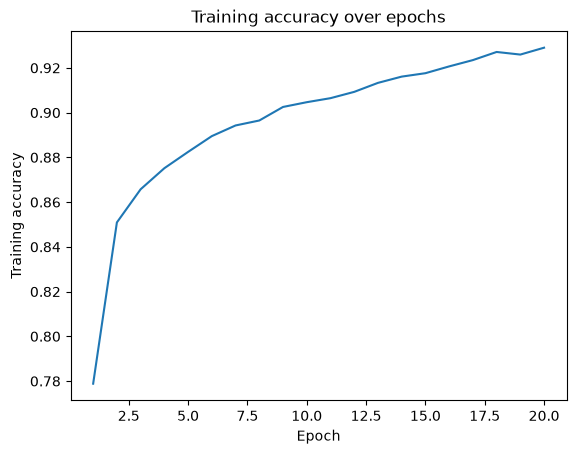

In [8]:
# Reuse history from Task 5
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_metrics"]) + 1)

plt.plot(epochs, history["train_metrics"])
plt.xlabel("Epoch")
plt.ylabel("Training accuracy")
plt.title("Training accuracy over epochs")
plt.show()
